## Image Processing Sample Code

To run this notebook you will just need the following packages installed: opencv, numpy, and matplotlib

In [1]:
# Load modules
from app.services.image_processing import read_image, segment_hough, segment_rect, visualize_masks, create_segmentation_gif, create_mean_value_image
import matplotlib.pyplot as plt

<Figure size 800x800 with 0 Axes>

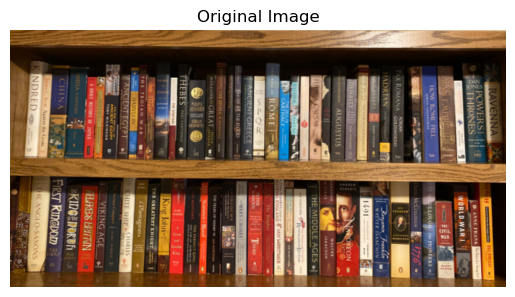

In [6]:
# Choose image
image_path = "images/bookshelf4.png"

# Read and display
image = read_image(image_path, max_dim=1024)

plt.figure(figsize=(8, 8))
fig, ax = plt.subplots()
ax.axis("off")
ax.set_title("Original Image")
ax.imshow(image)
plt.show()

Depth 0 | Split 1: score=0.861, direction=vertical, pos=806, child ratios=0.97, 0.03
Depth 1 | Split 2: score=0.878, direction=vertical, pos=761, child ratios=0.94, 0.06
Depth 2 | Split 3: score=0.863, direction=vertical, pos=716, child ratios=0.94, 0.06
Depth 3 | Split 4: score=0.808, direction=vertical, pos=31, child ratios=0.04, 0.96
Depth 4 | Split 5: score=0.906, direction=vertical, pos=67, child ratios=0.05, 0.95
Depth 5 | Split 6: score=0.735, direction=vertical, pos=638, child ratios=0.88, 0.12
Depth 6 | Split 7: score=0.998, direction=vertical, pos=598, child ratios=0.93, 0.07
Depth 7 | Split 8: score=0.870, direction=vertical, pos=498, child ratios=0.81, 0.19
Depth 8 | Split 9: score=0.993, direction=vertical, pos=443, child ratios=0.87, 0.13
Depth 9 | Split 10: score=1.129, direction=horizontal, pos=26, child ratios=0.06, 0.94
Depth 8 | Split 11: score=6.961, direction=horizontal, pos=31, child ratios=0.07, 0.93

Total segments: 11


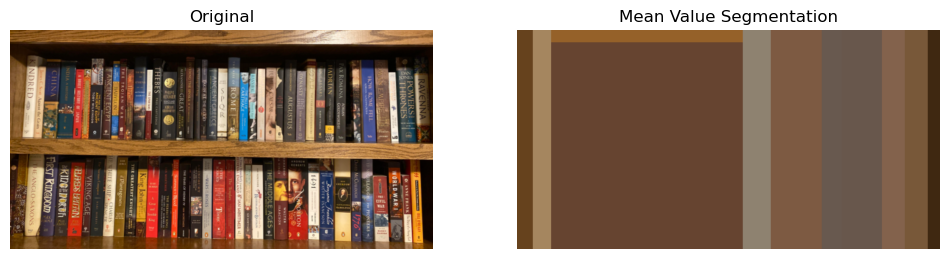

Depth 0: 1 segments
Depth 1: 2 segments
Depth 2: 2 segments
Depth 3: 2 segments
Depth 4: 2 segments
Depth 5: 2 segments
Depth 6: 2 segments
Depth 7: 2 segments
Depth 8: 2 segments
Depth 9: 2 segments
Depth 10: 2 segments

GIF saved to images/gifs/rect_segmentation.gif (13 frames)
Total leaf segments: 2


In [7]:
# Rectangular segmentation with verbose output
masks_rect = segment_rect(
    image, 
    min_size_factor=None,
    score_threshold=0.2,
    verbose=True
)

# Create mean-value visualization (still image)
mean_img_rect = create_mean_value_image(image, masks_rect)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_img_rect)
plt.title('Mean Value Segmentation')
plt.axis('off')
plt.show()

# Create animated GIFs showing the segmentation process
masks_rect_gif = create_segmentation_gif(
    image, 
    output_path='images/gifs/rect_segmentation.gif',
    method='rect',
    duration=300,  # 300ms per intermediate frame
    final_duration=2000,  # 2 seconds for final frame
    boundary_color=(255, 165, 0),  # Orange boundaries
    thickness=2,
    min_size_factor=None,
    score_threshold=0.2,
    verbose=True
)

Depth 0 | Split 1: score=0.043, child pixels=18061, 338839, child ratios=0.05, 0.95
Depth 1 | Split 2: score=0.038, child pixels=156951, 181888, child ratios=0.46, 0.54
Depth 2 | Split 3: score=0.070, child pixels=138890, 18061, child ratios=0.88, 0.12
Depth 3 | Split 4: score=0.099, child pixels=104276, 34614, child ratios=0.75, 0.25
Depth 4 | Split 5: score=0.309, child pixels=5761, 98515, child ratios=0.06, 0.94
Depth 4 | Split 6: score=0.092, child pixels=17596, 17018, child ratios=0.51, 0.49
Depth 5 | Split 7: score=0.094, child pixels=8198, 9398, child ratios=0.47, 0.53
Depth 5 | Split 8: score=0.113, child pixels=9755, 7263, child ratios=0.57, 0.43
Depth 2 | Split 9: score=0.025, child pixels=85998, 95890, child ratios=0.47, 0.53
Depth 3 | Split 10: score=0.032, child pixels=33539, 52459, child ratios=0.39, 0.61
Depth 4 | Split 11: score=0.045, child pixels=33110, 19349, child ratios=0.63, 0.37
Depth 3 | Split 12: score=0.266, child pixels=6690, 89200, child ratios=0.07, 0.93
De

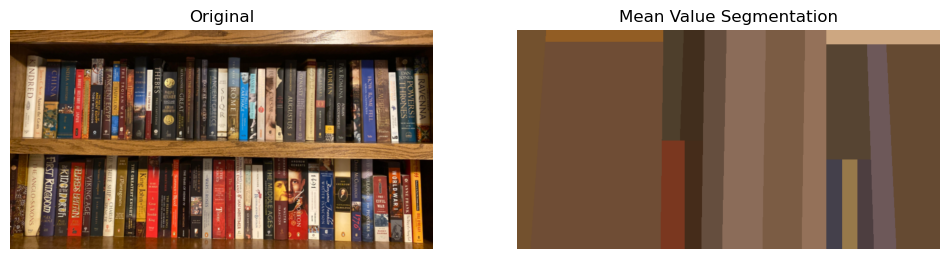

Depth 0: 1 segments
Depth 1: 2 segments
Depth 2: 4 segments
Depth 3: 4 segments
Depth 4: 8 segments
Depth 5: 12 segments
Depth 6: 6 segments
Depth 7: 4 segments
Depth 8: 8 segments
Depth 9: 8 segments
Depth 10: 4 segments

GIF saved to images/gifs/hough_segmentation.gif (13 frames)
Total leaf segments: 4


In [8]:
# Hough line segmentation with verbose output
masks_hough = segment_hough(
    image, 
    max_depth=10,
    min_score=0.05,
    verbose=True
)

# Create mean-value visualization (still image)
mean_img_hough = create_mean_value_image(image, masks_hough)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(mean_img_hough)
plt.title('Mean Value Segmentation')
plt.axis('off')
plt.show()

masks_hough_gif = create_segmentation_gif(
    image,
    output_path='images/gifs/hough_segmentation.gif', 
    method='hough',
    duration=300,
    final_duration=2000,
    boundary_color=(255, 165, 0),  # Green boundaries
    thickness=2,
    max_depth=10,
    min_score=0.05,
    verbose=True
)